In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from IPython.display import display, Markdown
from ipywidgets import interact, IntSlider, Checkbox
import ipywidgets as widgets

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

P = 113
key_freqs = (14, 35, 41, 42, 52)

print(f"Setup complete | P = {P} | Frequencies: {key_freqs}")

import plotly.graph_objects as go
from IPython.display import display

# Now this will work without a NameError
fig_w = go.FigureWidget()

Setup complete | P = 113 | Frequencies: (14, 35, 41, 42, 52)


In [26]:
def get_frequencies(P, key_freqs):
    return [2 * k * np.pi / P for k in key_freqs]

def embed(token, P, key_freqs):
    wks = get_frequencies(P, key_freqs)
    return [(np.cos(wk * token), np.sin(wk * token)) for wk in wks]

def combine_trig(embed_a, embed_b):
    combined = []
    for (cos_a, sin_a), (cos_b, sin_b) in zip(embed_a, embed_b):
        cos_sum = cos_a * cos_b - sin_a * sin_b
        sin_sum = sin_a * cos_b + cos_a * sin_b
        combined.append((cos_sum, sin_sum))
    return combined

def compute_logits(combined, P, key_freqs):
    wks = get_frequencies(P, key_freqs)
    logits = np.zeros(P)
    for c in range(P):
        for (cos_ab, sin_ab), wk in zip(combined, wks):
            logits[c] += cos_ab * np.cos(wk * c) + sin_ab * np.sin(wk * c)
    return logits

print("Core functions defined.")

Core functions defined.


In [27]:
display(Markdown(r"""
# Fourier Algorithm for Modular Addition

## Problem
Compute $(a + b) \bmod P$ where $P = 113$ (prime).

---

## Step 1: Fourier Embedding

$$t \;\mapsto\; \bigl(\cos(\omega_k \cdot t),\;\sin(\omega_k \cdot t)\bigr) \quad \text{for each } k \in \mathcal{K}$$

where $\omega_k = \dfrac{2\pi k}{P}$ and $\mathcal{K} = \{14, 35, 41, 42, 52\}$.

Each token becomes a **point on 5 unit circles** — one per frequency.

---

## Step 2: Trig Combination (the MLP's job)

The network applies the **angle addition identities**:

$$\cos(\omega_k(a+b)) = \cos(\omega_k a)\cos(\omega_k b) - \sin(\omega_k a)\sin(\omega_k b)$$
$$\sin(\omega_k(a+b)) = \sin(\omega_k a)\cos(\omega_k b) + \cos(\omega_k a)\sin(\omega_k b)$$

This is a bilinear operation — one hidden layer suffices.

---

## Step 3: Logit via Dot Product (Unembedding)

$$\text{logit}(c) = \sum_{k \in \mathcal{K}} \cos\bigl(\omega_k(a+b-c)\bigr)$$

Expanded:
$$= \sum_k \Bigl[\cos(\omega_k(a+b))\cos(\omega_k c) + \sin(\omega_k(a+b))\sin(\omega_k c)\Bigr]$$

---

## Step 4: Argmax

$$\hat{c} = \arg\max_c \;\text{logit}(c)$$

**Key insight:** At $c = (a+b) \bmod P$, every cosine term equals $\cos(0) = 1$:

$$\text{logit}\bigl((a+b) \bmod P\bigr) = |\mathcal{K}| = 5 \quad\text{(maximum possible)}$$

All other candidates get **destructive interference** $\to$ lower logits.
"""))



# Fourier Algorithm for Modular Addition

## Problem
Compute $(a + b) \bmod P$ where $P = 113$ (prime).

---

## Step 1: Fourier Embedding

$$t \;\mapsto\; \bigl(\cos(\omega_k \cdot t),\;\sin(\omega_k \cdot t)\bigr) \quad \text{for each } k \in \mathcal{K}$$

where $\omega_k = \dfrac{2\pi k}{P}$ and $\mathcal{K} = \{14, 35, 41, 42, 52\}$.

Each token becomes a **point on 5 unit circles** — one per frequency.

---

## Step 2: Trig Combination (the MLP's job)

The network applies the **angle addition identities**:

$$\cos(\omega_k(a+b)) = \cos(\omega_k a)\cos(\omega_k b) - \sin(\omega_k a)\sin(\omega_k b)$$
$$\sin(\omega_k(a+b)) = \sin(\omega_k a)\cos(\omega_k b) + \cos(\omega_k a)\sin(\omega_k b)$$

This is a bilinear operation — one hidden layer suffices.

---

## Step 3: Logit via Dot Product (Unembedding)

$$\text{logit}(c) = \sum_{k \in \mathcal{K}} \cos\bigl(\omega_k(a+b-c)\bigr)$$

Expanded:
$$= \sum_k \Bigl[\cos(\omega_k(a+b))\cos(\omega_k c) + \sin(\omega_k(a+b))\sin(\omega_k c)\Bigr]$$

---

## Step 4: Argmax

$$\hat{c} = \arg\max_c \;\text{logit}(c)$$

**Key insight:** At $c = (a+b) \bmod P$, every cosine term equals $\cos(0) = 1$:

$$\text{logit}\bigl((a+b) \bmod P\bigr) = |\mathcal{K}| = 5 \quad\text{(maximum possible)}$$

All other candidates get **destructive interference** $\to$ lower logits.


In [28]:
def full_pipeline(a, b):
    true_answer = (a + b) % P
    embed_a = embed(a, P, key_freqs)
    embed_b = embed(b, P, key_freqs)
    combined = combine_trig(embed_a, embed_b)
    logits = compute_logits(combined, P, key_freqs)
    prediction = np.argmax(logits)
    wks = get_frequencies(P, key_freqs)
    
    fig = plt.figure(figsize=(18, 20))
    fig.suptitle(f'({a} + {b}) mod {P} = {true_answer}  |  Prediction: {prediction}', 
                 fontsize=16, fontweight='bold')
    
    theta = np.linspace(0, 2*np.pi, 200)
    
    # === ROW 1: Embeddings on unit circles ===
    for idx, k in enumerate(key_freqs):
        ax = fig.add_subplot(5, 5, idx + 1)
        wk = wks[idx]
        ax.plot(np.cos(theta), np.sin(theta), 'k-', alpha=0.15)
        ax.axhline(0, color='gray', lw=0.3); ax.axvline(0, color='gray', lw=0.3)
        
        # All tokens faintly
        all_t = np.arange(P)
        ax.scatter(np.cos(wk*all_t), np.sin(wk*all_t), s=1, c='gray', alpha=0.2)
        
        # a, b, a+b
        ca, sa = embed_a[idx]
        cb, sb = embed_b[idx]
        cab, sab = combined[idx]
        
        ax.plot([0,ca],[0,sa],'r-', alpha=0.4); ax.plot(ca, sa, 'ro', ms=8, zorder=10)
        ax.plot([0,cb],[0,sb],'b-', alpha=0.4); ax.plot(cb, sb, 'bs', ms=8, zorder=10)
        ax.plot([0,cab],[0,sab],'g-', lw=2, alpha=0.6); ax.plot(cab, sab, 'g^', ms=10, zorder=10)
        
        ax.set_xlim(-1.4,1.4); ax.set_ylim(-1.4,1.4); ax.set_aspect('equal')
        ax.set_title(f'k={k}, w={wk:.3f}', fontsize=9)
    
    # === ROW 2: Trig combination bar charts ===
    for idx, k in enumerate(key_freqs):
        ax = fig.add_subplot(5, 5, 5 + idx + 1)
        ca, sa = embed_a[idx]
        cb, sb = embed_b[idx]
        cab, sab = combined[idx]
        
        x = np.arange(4)
        vals = [ca*cb, -sa*sb, cab, cab - (ca*cb - sa*sb)]
        colors_bar = ['coral','salmon','green','gray']
        labels = ['ca*cb', '-sa*sb', 'cos(a+b)', 'error']
        ax.bar(x, vals, color=colors_bar, edgecolor='black', lw=0.5)
        ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=6, rotation=20)
        ax.set_ylim(-1.2, 1.2); ax.axhline(0, color='k', lw=0.5)
        ax.set_title(f'k={k}: trig identity', fontsize=8)
    
    # === ROW 3: Per-frequency cosine waves ===
    c_vals = np.arange(P)
    for idx, (k, wk) in enumerate(zip(key_freqs, wks)):
        ax = fig.add_subplot(5, 5, 10 + idx + 1)
        cab, sab = combined[idx]
        wave = cab * np.cos(wk * c_vals) + sab * np.sin(wk * c_vals)
        
        ax.plot(c_vals, wave, '-', lw=1, color=f'C{idx}')
        ax.fill_between(c_vals, wave, 0, alpha=0.1, color=f'C{idx}')
        ax.axvline(true_answer, color='red', ls='--', lw=1.5)
        ax.plot(true_answer, wave[true_answer], 'r*', ms=12, zorder=10)
        ax.axhline(0, color='gray', lw=0.5)
        ax.set_ylim(-1.3, 1.3)
        ax.set_title(f'k={k}: cos(w*(a+b-c))', fontsize=8)
        ax.set_xlabel('c', fontsize=7)
    
    # === ROW 4: Summed logits ===
    ax4 = fig.add_subplot(5, 1, 4)
    bar_colors = ['limegreen' if c == true_answer else 'steelblue' for c in range(P)]
    ax4.bar(range(P), logits, color=bar_colors, width=1.0)
    ax4.axvline(true_answer, color='red', ls='--', lw=2, label=f'True: {true_answer}')
    ax4.axhline(len(key_freqs), color='orange', ls=':', lw=1.5, label=f'Max={len(key_freqs)}')
    ax4.set_xlim(-1, P); ax4.set_xlabel('c'); ax4.set_ylabel('logit(c)')
    status = "CORRECT" if prediction == true_answer else "WRONG"
    ax4.set_title(f'Logits | argmax={prediction} | {status}', fontsize=12, fontweight='bold',
                 color='green' if prediction == true_answer else 'red')
    ax4.legend()
    
    # === ROW 5: Heatmap ===
    ax5 = fig.add_subplot(5, 1, 5)
    contributions = np.zeros((len(key_freqs), P))
    for fi, ((cab, sab), wk) in enumerate(zip(combined, wks)):
        contributions[fi] = cab * np.cos(wk * c_vals) + sab * np.sin(wk * c_vals)
    
    im = ax5.imshow(contributions, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
    ax5.set_yticks(range(len(key_freqs)))
    ax5.set_yticklabels([f'k={k}' for k in key_freqs])
    ax5.set_xlabel('c'); ax5.set_title('Per-freq contributions (all=1 at true answer)')
    ax5.axvline(true_answer, color='lime', lw=2)
    plt.colorbar(im, ax=ax5, shrink=0.7)
    
    fig.subplots_adjust(hspace=0.5, wspace=0.4, top=0.94, bottom=0.03)
    plt.show()
    
    # Summary
    margin = np.sort(logits)[-1] - np.sort(logits)[-2]
    print(f"  ({a} + {b}) mod {P} = {true_answer} | pred = {prediction} | "
          f"logit = {logits[true_answer]:.4f}/{len(key_freqs)} | margin = {margin:.4f}")

interact(full_pipeline,
         a=IntSlider(value=23, min=0, max=112, description='a:'),
         b=IntSlider(value=47, min=0, max=112, description='b:'));


interactive(children=(IntSlider(value=23, description='a:', max=112), IntSlider(value=47, description='b:', ma…

In [35]:
import time
from IPython.display import clear_output

def animated_buildup(a=23, b=47, delay=0.6):
    """Animate the logit curve sharpening as frequencies are added one by one."""
    true_answer = (a + b) % P
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    c_vals = np.arange(P)
    cumulative_logits = np.zeros(P)
    
    colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
    
    for step, k in enumerate(key_freqs):
        active = key_freqs[:step+1]
        wk = 2 * k * np.pi / P
        
        # Compute this frequency's contribution
        ea = embed(a, P, (k,))
        eb = embed(b, P, (k,))
        comb = combine_trig(ea, eb)
        cab, sab = comb[0]
        wave = cab * np.cos(wk * c_vals) + sab * np.sin(wk * c_vals)
        cumulative_logits += wave
        
        # Clear and redraw
        ax1.cla(); ax2.cla()
        
        # Top: individual waves stacked
        for prev_idx in range(step + 1):
            prev_k = key_freqs[prev_idx]
            prev_wk = 2 * prev_k * np.pi / P
            prev_ea = embed(a, P, (prev_k,))
            prev_eb = embed(b, P, (prev_k,))
            prev_comb = combine_trig(prev_ea, prev_eb)
            prev_cab, prev_sab = prev_comb[0]
            prev_wave = prev_cab * np.cos(prev_wk * c_vals) + prev_sab * np.sin(prev_wk * c_vals)
            alpha = 1.0 if prev_idx == step else 0.3
            ax1.plot(c_vals, prev_wave, color=colors[prev_idx], lw=2 if prev_idx == step else 1, 
                     alpha=alpha, label=f'k={prev_k}')
        
        ax1.axvline(true_answer, color='red', ls='--', lw=2, alpha=0.7)
        ax1.set_ylim(-1.4, 1.4)
        ax1.set_title(f'Step {step+1}/5: Adding frequency k={k}', fontsize=14, fontweight='bold')
        ax1.legend(loc='upper right', ncol=5)
        ax1.set_ylabel('cos(ωₖ(a+b−c))')
        
        # Bottom: cumulative logit
        bar_colors = ['limegreen' if c == true_answer else 'steelblue' for c in range(P)]
        ax2.bar(range(P), cumulative_logits, color=bar_colors, width=1.0)
        ax2.axvline(true_answer, color='red', ls='--', lw=2)
        ax2.axhline(step + 1, color='orange', ls=':', lw=2, label=f'Max possible = {step+1}')
        ax2.set_xlim(-1, P)
        ax2.set_ylim(-3, len(key_freqs) + 0.5)
        ax2.set_xlabel('c')
        ax2.set_ylabel('Cumulative logit(c)')
        ax2.set_title(f'Summed logits ({step+1} frequencies) — Peak at c={true_answer}: {cumulative_logits[true_answer]:.2f}',
                     fontsize=12, fontweight='bold',
                     color='green' if np.argmax(cumulative_logits) == true_answer else 'red')
        ax2.legend()
        
        # Add annotation arrow pointing at the peak
        ax2.annotate(f'← ANSWER\n   logit={cumulative_logits[true_answer]:.2f}',
                    xy=(true_answer, cumulative_logits[true_answer]),
                    xytext=(true_answer + 15, cumulative_logits[true_answer] - 0.5),
                    fontsize=10, fontweight='bold', color='darkgreen',
                    arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2))
        
        plt.tight_layout()
        clear_output(wait=True)
        display(fig)
        
        if step < len(key_freqs) - 1:
            time.sleep(delay)
    
    plt.close(fig)

# Interactive wrapper
from ipywidgets import interact, IntSlider, FloatSlider

interact(animated_buildup,
         a=IntSlider(value=23, min=0, max=112, description='a:'),
         b=IntSlider(value=47, min=0, max=112, description='b:'),
         delay=FloatSlider(value=0.6, min=0.1, max=2.0, step=0.1, description='Delay (s):'));


interactive(children=(IntSlider(value=23, description='a:', max=112), IntSlider(value=47, description='b:', ma…

<Figure size 640x480 with 0 Axes>

In [37]:
display(Markdown(r"""
## Frequency Explorer

Toggle individual frequencies to see how the logit peak **sharpens** with more frequencies.

- 1 frequency: broad cosine, many near-ties
- 5 frequencies: sharp spike at the correct answer (constructive interference)
"""))

def freq_explorer(a, b, k14, k35, k41, k42, k52):
    active = []
    if k14: active.append(14)
    if k35: active.append(35)
    if k41: active.append(41)
    if k42: active.append(42)
    if k52: active.append(52)
    
    if not active:
        print("Select at least one frequency!"); return
    
    active = tuple(active)
    true_answer = (a + b) % P
    ea = embed(a, P, active)
    eb = embed(b, P, active)
    comb = combine_trig(ea, eb)
    logits = compute_logits(comb, P, active)
    pred = np.argmax(logits)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))
    
    # Individual waves
    wks = get_frequencies(P, active)
    c_vals = np.arange(P)
    for i, (k, wk, (cab, sab)) in enumerate(zip(active, wks, comb)):
        wave = cab * np.cos(wk * c_vals) + sab * np.sin(wk * c_vals)
        ax1.plot(c_vals, wave, lw=1.2, alpha=0.7, label=f'k={k}')
    ax1.axvline(true_answer, color='red', ls='--', lw=2)
    ax1.set_title(f'{len(active)} active frequencies'); ax1.legend(ncol=5); ax1.set_ylim(-1.3,1.3)
    
    # Summed logits
    bar_c = ['limegreen' if c == true_answer else 'steelblue' for c in range(P)]
    ax2.bar(range(P), logits, color=bar_c, width=1.0)
    ax2.axvline(true_answer, color='red', ls='--', lw=2)
    ax2.axhline(len(active), color='orange', ls=':', lw=1.5)
    ax2.set_xlim(-1, P)
    status = "CORRECT" if pred == true_answer else "WRONG"
    ax2.set_title(f'Logits | pred={pred} | {status} | margin={logits[pred]-np.sort(logits)[-2]:.3f}',
                 fontweight='bold', color='green' if pred == true_answer else 'red')
    
    plt.tight_layout(); plt.show()

interact(freq_explorer,
         a=IntSlider(value=23, min=0, max=112, description='a:'),
         b=IntSlider(value=47, min=0, max=112, description='b:'),
         k14=Checkbox(value=True, description='k=14'),
         k35=Checkbox(value=True, description='k=35'),
         k41=Checkbox(value=True, description='k=41'),
         k42=Checkbox(value=True, description='k=42'),
         k52=Checkbox(value=True, description='k=52'));



## Frequency Explorer

Toggle individual frequencies to see how the logit peak **sharpens** with more frequencies.

- 1 frequency: broad cosine, many near-ties
- 5 frequencies: sharp spike at the correct answer (constructive interference)


interactive(children=(IntSlider(value=23, description='a:', max=112), IntSlider(value=47, description='b:', ma…

In [31]:
display(Markdown(r"""
## Constructive vs Destructive Interference

At the **correct** answer $c^* = (a+b) \bmod P$:
$$\cos(\omega_k(a+b - c^*)) = \cos(0) = 1 \quad \forall k$$

At any **wrong** answer $c \neq c^*$:
$$\cos(\omega_k(a+b - c)) \text{ are different phases} \to \text{they cancel out}$$

This is identical to how a **phased antenna array** focuses a beam!
"""))

def interference_detail(a, b, c_offset):
    true_answer = (a + b) % P
    c_test = (true_answer + c_offset) % P
    
    ea = embed(a, P, key_freqs)
    eb = embed(b, P, key_freqs)
    comb = combine_trig(ea, eb)
    wks = get_frequencies(P, key_freqs)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: phasor diagram
    ax = axes[0]
    total_real = 0
    total_imag = 0
    for i, (k, wk, (cab, sab)) in enumerate(zip(key_freqs, wks, comb)):
        contrib = cab * np.cos(wk * c_test) + sab * np.sin(wk * c_test)
        # Draw as phasor (contribution is real, but show as vector for intuition)
        angle = wk * ((a+b) - c_test)
        dx, dy = np.cos(angle), np.sin(angle)
        ax.arrow(0, i, dx*0.9, 0, head_width=0.15, head_length=0.05, 
                fc=f'C{i}', ec=f'C{i}', lw=2)
        ax.text(dx + 0.1, i, f'k={k}: {contrib:+.3f}', fontsize=9, va='center')
        total_real += contrib
    
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_xlim(-1.5, 1.8); ax.set_ylim(-0.5, len(key_freqs)-0.5)
    ax.set_yticks([]); ax.set_xlabel('Contribution')
    is_correct = c_offset == 0
    ax.set_title(f'c={c_test} (offset={c_offset}) | Sum={total_real:.3f}\n'
                f'{"CORRECT - all positive!" if is_correct else "Wrong - partial cancellation"}',
                color='green' if is_correct else 'red', fontweight='bold')
    
    # Right: bar chart of contributions
    ax2 = axes[1]
    contribs = []
    for wk, (cab, sab) in zip(wks, comb):
        contribs.append(cab * np.cos(wk * c_test) + sab * np.sin(wk * c_test))
    
    colors_b = ['green' if v > 0.9 else 'coral' if v < 0 else 'gold' for v in contribs]
    ax2.bar(range(len(key_freqs)), contribs, color=colors_b, edgecolor='black')
    ax2.set_xticks(range(len(key_freqs)))
    ax2.set_xticklabels([f'k={k}' for k in key_freqs])
    ax2.axhline(0, color='k', lw=0.5)
    ax2.axhline(1, color='green', ls=':', alpha=0.5)
    ax2.set_ylim(-1.2, 1.2)
    ax2.set_ylabel('cos(w_k*(a+b-c))')
    ax2.set_title(f'Per-frequency contributions at c={c_test}\nTotal logit = {sum(contribs):.3f}')
    
    plt.tight_layout(); plt.show()

interact(interference_detail,
         a=IntSlider(value=23, min=0, max=112, description='a:'),
         b=IntSlider(value=47, min=0, max=112, description='b:'),
         c_offset=IntSlider(value=0, min=0, max=112, description='c offset:'));



## Constructive vs Destructive Interference

At the **correct** answer $c^* = (a+b) \bmod P$:
$$\cos(\omega_k(a+b - c^*)) = \cos(0) = 1 \quad \forall k$$

At any **wrong** answer $c \neq c^*$:
$$\cos(\omega_k(a+b - c)) \text{ are different phases} \to \text{they cancel out}$$

This is identical to how a **phased antenna array** focuses a beam!


interactive(children=(IntSlider(value=23, description='a:', max=112), IntSlider(value=47, description='b:', ma…


## Full Accuracy Test

Testing **all** $113 \times 113 = 12{,}769$ input pairs.
The algorithm achieves 100% accuracy because it's an exact mathematical identity, not an approximation.


Accuracy: 12769/12769 = 100.00%


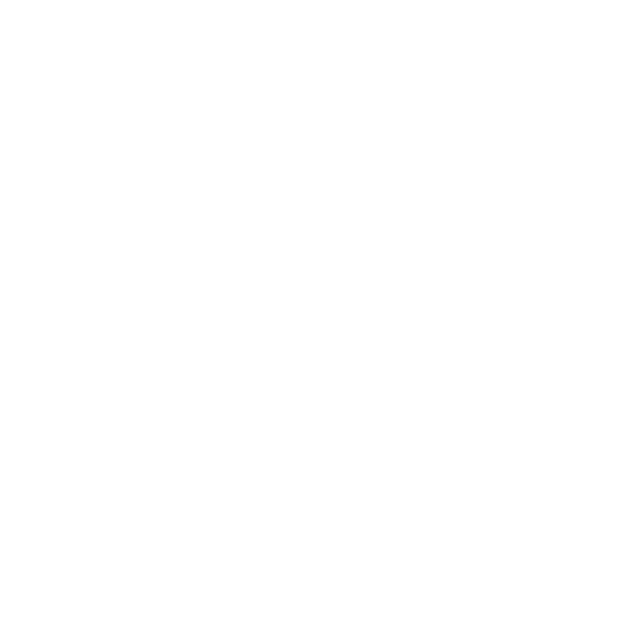

In [32]:
display(Markdown(r"""
## Full Accuracy Test

Testing **all** $113 \times 113 = 12{,}769$ input pairs.
The algorithm achieves 100% accuracy because it's an exact mathematical identity, not an approximation.
"""))

# Compute accuracy for all pairs
correct_map = np.zeros((P, P), dtype=bool)
for a_t in range(P):
    ea = embed(a_t, P, key_freqs)
    for b_t in range(P):
        eb = embed(b_t, P, key_freqs)
        comb = combine_trig(ea, eb)
        logits = compute_logits(comb, P, key_freqs)
        correct_map[a_t, b_t] = (np.argmax(logits) == (a_t + b_t) % P)

accuracy = correct_map.sum() / correct_map.size
print(f"Accuracy: {correct_map.sum()}/{correct_map.size} = {accuracy:.2%}")

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(correct_map, cmap='RdYlGn', vmin=0, vmax=1, interpolation='nearest')
ax.set_xlabel('b'); ax.set_ylabel('a')
ax.set_title(f'Correctness for all (a,b) pairs | Accuracy = {accuracy:.2%}', fontweight='bold')
plt.tight_layout(); plt.show()



## Confidence Analysis: Logit Margins

The **margin** = logit(correct answer) - logit(2nd best).  
Larger margin = more confident prediction.

Since all 5 frequencies align perfectly at the answer, the margin is always large.


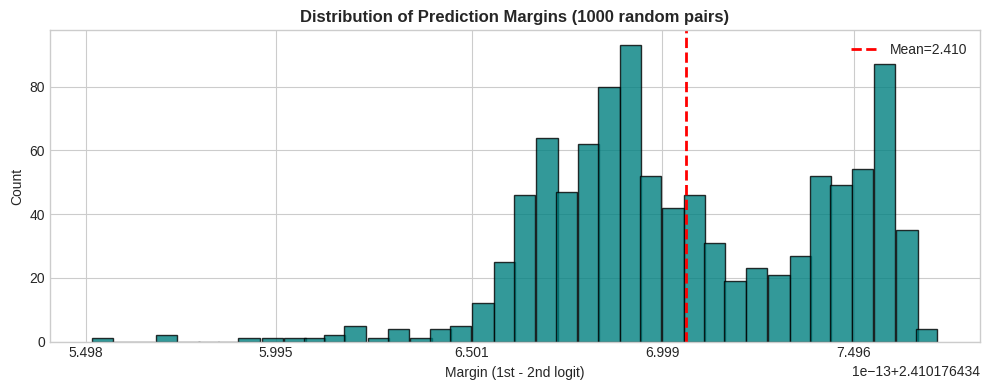

Min margin: 2.4102 | Mean: 2.4102 | Max: 2.4102


In [33]:
display(Markdown(r"""
## Confidence Analysis: Logit Margins

The **margin** = logit(correct answer) - logit(2nd best).  
Larger margin = more confident prediction.

Since all 5 frequencies align perfectly at the answer, the margin is always large.
"""))

margins = []
for _ in range(1000):
    a_s, b_s = np.random.randint(0, P, 2)
    ea = embed(a_s, P, key_freqs)
    eb = embed(b_s, P, key_freqs)
    comb = combine_trig(ea, eb)
    logits = compute_logits(comb, P, key_freqs)
    sorted_l = np.sort(logits)[::-1]
    margins.append(sorted_l[0] - sorted_l[1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(margins, bins=40, color='teal', edgecolor='black', alpha=0.8)
ax.axvline(np.mean(margins), color='red', ls='--', lw=2, label=f'Mean={np.mean(margins):.3f}')
ax.set_xlabel('Margin (1st - 2nd logit)'); ax.set_ylabel('Count')
ax.set_title('Distribution of Prediction Margins (1000 random pairs)', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()
print(f"Min margin: {min(margins):.4f} | Mean: {np.mean(margins):.4f} | Max: {max(margins):.4f}")


In [34]:
import numpy as np
import plotly.graph_objects as go
from ipywidgets import IntSlider, VBox, HBox, Button, Label, Checkbox
from IPython.display import display
import time
import threading

# === Static data ===
P = 113
w1 = 2 * 14 * np.pi / P
w2 = 2 * 35 * np.pi / P
tokens = np.arange(P)

x_all = np.cos(w1 * tokens)
y_all = np.sin(w1 * tokens)
z_all = np.cos(w2 * tokens)

# === Trail history storage ===
trail_a = {'x': [], 'y': [], 'z': []}
trail_b = {'x': [], 'y': [], 'z': []}
trail_ans = {'x': [], 'y': [], 'z': []}

# === Build FigureWidget ===
fig_w = go.FigureWidget()

# Trace 0: all tokens (background)
fig_w.add_trace(go.Scatter3d(
    x=x_all, y=y_all, z=z_all,
    mode='markers',
    marker=dict(size=3, color=tokens.tolist(), colorscale='Viridis', opacity=0.4,
                colorbar=dict(title=dict(text='Token', font=dict(size=14)))),
    name='All tokens',
    text=[f't={t}' for t in tokens],
    hovertemplate='Token %{text}<extra></extra>'
))

# Trace 1: trajectory line (torus skeleton)
fig_w.add_trace(go.Scatter3d(
    x=x_all, y=y_all, z=z_all,
    mode='lines', line=dict(color='gray', width=1), opacity=0.15,
    showlegend=False, hoverinfo='skip'
))

# Trace 2: point a
fig_w.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0], mode='markers',
    marker=dict(size=16, color='red', opacity=1, line=dict(color='darkred', width=2)),
    name='a', hoverinfo='name'
))

# Trace 3: point b
fig_w.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0], mode='markers',
    marker=dict(size=16, color='dodgerblue', opacity=1, line=dict(color='darkblue', width=2)),
    name='b', hoverinfo='name'
))

# Trace 4: answer
fig_w.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0], mode='markers',
    marker=dict(size=20, color='lime', opacity=1, symbol='diamond',
                line=dict(color='darkgreen', width=3)),
    name='answer', hoverinfo='name'
))

# Trace 5: line a -> answer
fig_w.add_trace(go.Scatter3d(
    x=[0, 0], y=[0, 0], z=[0, 0],
    mode='lines', line=dict(color='red', width=5, dash='dash'),
    showlegend=False, hoverinfo='skip'
))

# Trace 6: line b -> answer
fig_w.add_trace(go.Scatter3d(
    x=[0, 0], y=[0, 0], z=[0, 0],
    mode='lines', line=dict(color='dodgerblue', width=5, dash='dash'),
    showlegend=False, hoverinfo='skip'
))

# Trace 7: trail for point a
fig_w.add_trace(go.Scatter3d(
    x=[], y=[], z=[],
    mode='lines+markers',
    line=dict(color='red', width=3),
    marker=dict(size=2, color='red', opacity=0.6),
    opacity=0.5,
    name='Trail a',
    hoverinfo='skip'
))

# Trace 8: trail for point b
fig_w.add_trace(go.Scatter3d(
    x=[], y=[], z=[],
    mode='lines+markers',
    line=dict(color='dodgerblue', width=3),
    marker=dict(size=2, color='dodgerblue', opacity=0.6),
    opacity=0.5,
    name='Trail b',
    hoverinfo='skip'
))

# Trace 9: trail for answer
fig_w.add_trace(go.Scatter3d(
    x=[], y=[], z=[],
    mode='lines+markers',
    line=dict(color='lime', width=3),
    marker=dict(size=2, color='lime', opacity=0.6),
    opacity=0.5,
    name='Trail answer',
    hoverinfo='skip'
))

fig_w.update_layout(
    scene=dict(
        xaxis=dict(title=dict(text='cos(w_14 * t)', font=dict(size=13))),
        yaxis=dict(title=dict(text='sin(w_14 * t)', font=dict(size=13))),
        zaxis=dict(title=dict(text='cos(w_35 * t)', font=dict(size=13))),
        camera=dict(eye=dict(x=1.5, y=1.5, z=0.8)),
        aspectmode='cube',
        annotations=[]
    ),
    width=900, height=700,
    showlegend=True,
    legend=dict(font=dict(size=14), x=0.01, y=0.99),
    title=dict(text='Drag to rotate | Use sliders', font=dict(size=20)),
    margin=dict(t=60, b=10),
    uirevision='keep'
)

# === Slider callback ===
def update_3d(change):
    a = slider_a.value
    b = slider_b.value
    ans = (a + b) % P

    ax, ay, az = np.cos(w1*a), np.sin(w1*a), np.cos(w2*a)
    bx, by, bz = np.cos(w1*b), np.sin(w1*b), np.cos(w2*b)
    cx, cy, cz = np.cos(w1*ans), np.sin(w1*ans), np.cos(w2*ans)

    # Append to trails if trail recording is on
    if chk_record_trail.value:
        trail_a['x'].append(ax)
        trail_a['y'].append(ay)
        trail_a['z'].append(az)
        trail_b['x'].append(bx)
        trail_b['y'].append(by)
        trail_b['z'].append(bz)
        trail_ans['x'].append(cx)
        trail_ans['y'].append(cy)
        trail_ans['z'].append(cz)

    # Limit trail length to avoid performance issues
    max_trail = trail_length_slider.value
    for trail in [trail_a, trail_b, trail_ans]:
        for key in trail:
            if len(trail[key]) > max_trail:
                trail[key] = trail[key][-max_trail:]

    with fig_w.batch_update():
        fig_w.data[2].x, fig_w.data[2].y, fig_w.data[2].z = [ax], [ay], [az]
        fig_w.data[2].name = f'a = {a}'

        fig_w.data[3].x, fig_w.data[3].y, fig_w.data[3].z = [bx], [by], [bz]
        fig_w.data[3].name = f'b = {b}'

        fig_w.data[4].x, fig_w.data[4].y, fig_w.data[4].z = [cx], [cy], [cz]
        fig_w.data[4].name = f'({a}+{b})%{P} = {ans}'

        fig_w.data[5].x, fig_w.data[5].y, fig_w.data[5].z = [ax, cx], [ay, cy], [az, cz]
        fig_w.data[6].x, fig_w.data[6].y, fig_w.data[6].z = [bx, cx], [by, cy], [bz, cz]

        # Update trails
        fig_w.data[7].x = trail_a['x']
        fig_w.data[7].y = trail_a['y']
        fig_w.data[7].z = trail_a['z']

        fig_w.data[8].x = trail_b['x']
        fig_w.data[8].y = trail_b['y']
        fig_w.data[8].z = trail_b['z']

        fig_w.data[9].x = trail_ans['x']
        fig_w.data[9].y = trail_ans['y']
        fig_w.data[9].z = trail_ans['z']

        # 3D scene annotations
        fig_w.layout.scene.annotations = [
            dict(x=ax, y=ay, z=az, text=f'a={a}', showarrow=True,
                 arrowhead=2, arrowsize=1, arrowwidth=2, arrowcolor='red',
                 font=dict(size=18, color='red'),
                 bgcolor='rgba(255,255,255,0.85)', bordercolor='red', borderwidth=2),
            dict(x=bx, y=by, z=bz, text=f'b={b}', showarrow=True,
                 arrowhead=2, arrowsize=1, arrowwidth=2, arrowcolor='dodgerblue',
                 font=dict(size=18, color='dodgerblue'),
                 bgcolor='rgba(255,255,255,0.85)', bordercolor='dodgerblue', borderwidth=2),
            dict(x=cx, y=cy, z=cz, text=f'({a}+{b})%{P} = {ans}', showarrow=True,
                 arrowhead=2, arrowsize=1, arrowwidth=2, arrowcolor='green',
                 font=dict(size=18, color='green'),
                 bgcolor='rgba(255,255,255,0.85)', bordercolor='green', borderwidth=2,
                 ay=-50),
        ]

        fig_w.layout.title.text = f'({a} + {b}) mod {P} = {ans}'

# === Sliders ===
slider_a = IntSlider(value=23, min=0, max=112, step=1, description='a:',
                     continuous_update=False,
                     style={'description_width': '30px', 'handle_color': 'red'},
                     layout={'width': '400px'})
slider_b = IntSlider(value=47, min=0, max=112, step=1, description='b:',
                     continuous_update=False,
                     style={'description_width': '30px', 'handle_color': 'dodgerblue'},
                     layout={'width': '400px'})

slider_a.observe(update_3d, names='value')
slider_b.observe(update_3d, names='value')

# === +/- Buttons for slider a ===
btn_a_minus = Button(description='−', layout={'width': '40px'}, button_style='danger')
btn_a_plus = Button(description='+', layout={'width': '40px'}, button_style='danger')

def on_a_minus(btn):
    slider_a.value = max(slider_a.min, slider_a.value - 1)
def on_a_plus(btn):
    slider_a.value = min(slider_a.max, slider_a.value + 1)

btn_a_minus.on_click(on_a_minus)
btn_a_plus.on_click(on_a_plus)

# === +/- Buttons for slider b ===
btn_b_minus = Button(description='−', layout={'width': '40px'}, button_style='info')
btn_b_plus = Button(description='+', layout={'width': '40px'}, button_style='info')

def on_b_minus(btn):
    slider_b.value = max(slider_b.min, slider_b.value - 1)
def on_b_plus(btn):
    slider_b.value = min(slider_b.max, slider_b.value + 1)

btn_b_minus.on_click(on_b_minus)
btn_b_plus.on_click(on_b_plus)

# === Trail controls ===
chk_record_trail = Checkbox(value=True, description='Record trails',
                            style={'description_width': 'initial'},
                            layout={'width': '150px'})

trail_length_slider = IntSlider(value=200, min=10, max=2000, step=10,
                                description='Trail length:',
                                continuous_update=False,
                                style={'description_width': '90px'},
                                layout={'width': '300px'})

btn_clear_trails = Button(description='🗑 Clear Trails', button_style='warning',
                          layout={'width': '130px'})

def clear_trails(btn):
    for trail in [trail_a, trail_b, trail_ans]:
        trail['x'].clear()
        trail['y'].clear()
        trail['z'].clear()
    with fig_w.batch_update():
        for i in [7, 8, 9]:
            fig_w.data[i].x = []
            fig_w.data[i].y = []
            fig_w.data[i].z = []

btn_clear_trails.on_click(clear_trails)

# === Auto Animate Button ===
btn_animate = Button(description='▶ Auto Animate', button_style='success',
                     layout={'width': '150px'})
btn_stop = Button(description='⏹ Stop', button_style='warning',
                  layout={'width': '100px'})
status_label = Label(value='')

speed_slider = IntSlider(value=50, min=10, max=500, step=10,
                         description='Delay (ms):',
                         continuous_update=False,
                         style={'description_width': '80px'},
                         layout={'width': '280px'})

animation_running = {'value': False}

def animate_all(btn):
    """Cycle through all (a, b) combinations."""
    if animation_running['value']:
        return
    animation_running['value'] = True
    status_label.value = '🔄 Animating...'

    def run_animation():
        for a_val in range(P):
            if not animation_running['value']:
                break
            slider_a.value = a_val
            for b_val in range(P):
                if not animation_running['value']:
                    break
                slider_b.value = b_val
                time.sleep(speed_slider.value / 1000.0)

        animation_running['value'] = False
        status_label.value = '✅ Done!' if status_label.value == '🔄 Animating...' else '⏹ Stopped'

    thread = threading.Thread(target=run_animation, daemon=True)
    thread.start()

def stop_animation(btn):
    animation_running['value'] = False
    status_label.value = '⏹ Stopped'

btn_animate.on_click(animate_all)
btn_stop.on_click(stop_animation)

# === Layout ===
row_a = HBox([btn_a_minus, slider_a, btn_a_plus])
row_b = HBox([btn_b_minus, slider_b, btn_b_plus])
anim_row = HBox([btn_animate, btn_stop, speed_slider, status_label])
trail_row = HBox([chk_record_trail, trail_length_slider, btn_clear_trails])

update_3d(None)
display(VBox([row_a, row_b, anim_row, trail_row, fig_w]))

In [38]:
import plotly.graph_objects as go
from ipywidgets import IntSlider, VBox, HBox
from IPython.display import display

P = 113
w1 = 2 * 14 * np.pi / P
w2 = 2 * 35 * np.pi / P
tokens = np.arange(P)

x_all = np.cos(w1 * tokens)
y_all = np.sin(w1 * tokens)
z_all = np.cos(w2 * tokens)

# === Build torus wireframe ===
# The tokens lie on a torus-like structure in this 3D projection
# We'll draw a parametric wireframe to show the manifold
theta_mesh = np.linspace(0, 2*np.pi, 50)
phi_mesh = np.linspace(0, 2*np.pi, 50)

# The "torus" in this projection: x=cos(w1*t), y=sin(w1*t), z=cos(w2*t)
# We can show the envelope by plotting curves at fixed w1*t and varying w2*t
wireframe_traces = []

# Longitudinal lines (fixed phase on freq 14, vary freq 35)
for t_val in np.linspace(0, P, 12, endpoint=False):
    wf_t = np.linspace(t_val, t_val + P/14, 30)  # one period of freq 14
    wireframe_traces.append(go.Scatter3d(
        x=np.cos(w1 * wf_t), y=np.sin(w1 * wf_t), z=np.cos(w2 * wf_t),
        mode='lines', line=dict(color='rgba(150,150,150,0.15)', width=1),
        showlegend=False, hoverinfo='skip'
    ))

# === Build FigureWidget ===
fig_w = go.FigureWidget()

# Add wireframe traces
for trace in wireframe_traces:
    fig_w.add_trace(trace)

# All tokens (background)
fig_w.add_trace(go.Scatter3d(
    x=x_all.tolist(), y=y_all.tolist(), z=z_all.tolist(),
    mode='markers',
    marker=dict(size=3, color=tokens.tolist(), colorscale='Viridis', opacity=0.4,
                colorbar=dict(title=dict(text='Token', font=dict(size=14)))),
    name='All tokens',
    text=[f't={t}' for t in tokens],
    hovertemplate='Token %{text}<extra></extra>'
))

# Trajectory line
fig_w.add_trace(go.Scatter3d(
    x=x_all.tolist(), y=y_all.tolist(), z=z_all.tolist(),
    mode='lines', line=dict(color='gray', width=1.5), opacity=0.2,
    showlegend=False, hoverinfo='skip'
))

# Point a
fig_w.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0], mode='markers',
    marker=dict(size=16, color='red', opacity=1, line=dict(color='darkred', width=2)),
    name='a', hoverinfo='name'
))

# Point b
fig_w.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0], mode='markers',
    marker=dict(size=16, color='dodgerblue', opacity=1, line=dict(color='darkblue', width=2)),
    name='b', hoverinfo='name'
))

# Answer point
fig_w.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0], mode='markers',
    marker=dict(size=20, color='lime', opacity=1, symbol='diamond',
                line=dict(color='darkgreen', width=3)),
    name='answer', hoverinfo='name'
))

# Geodesic path from a to answer (along the torus surface)
fig_w.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='lines', line=dict(color='gold', width=6),
    name='Geodesic a→ans', hoverinfo='skip'
))

# Geodesic path from b to answer
fig_w.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='lines', line=dict(color='cyan', width=6),
    name='Geodesic b→ans', hoverinfo='skip'
))

n_wireframe = len(wireframe_traces)

fig_w.update_layout(
    scene=dict(
        xaxis=dict(title=dict(text='cos(ω₁₄·t)', font=dict(size=13))),
        yaxis=dict(title=dict(text='sin(ω₁₄·t)', font=dict(size=13))),
        zaxis=dict(title=dict(text='cos(ω₃₅·t)', font=dict(size=13))),
        camera=dict(eye=dict(x=1.5, y=1.5, z=0.8)),
        aspectmode='cube',
    ),
    width=900, height=700,
    showlegend=True,
    legend=dict(font=dict(size=13), x=0.01, y=0.99),
    title=dict(text='Torus Embedding with Geodesic Paths', font=dict(size=18)),
    margin=dict(t=60, b=10),
    uirevision='keep'
)

def update_torus_3d(change):
    a = slider_a_t.value
    b = slider_b_t.value
    ans = (a + b) % P

    ax_v, ay_v, az_v = np.cos(w1*a), np.sin(w1*a), np.cos(w2*a)
    bx_v, by_v, bz_v = np.cos(w1*b), np.sin(w1*b), np.cos(w2*b)
    cx_v, cy_v, cz_v = np.cos(w1*ans), np.sin(w1*ans), np.cos(w2*ans)

    # Geodesic from a to answer (interpolate along the torus)
    if ans >= a:
        geo_a_t = np.linspace(a, ans, 30)
    else:
        geo_a_t = np.linspace(a, ans + P, 30) % P
    
    geo_a_x = np.cos(w1 * geo_a_t)
    geo_a_y = np.sin(w1 * geo_a_t)
    geo_a_z = np.cos(w2 * geo_a_t)
    
    # Geodesic from b to answer
    if ans >= b:
        geo_b_t = np.linspace(b, ans, 30)
    else:
        geo_b_t = np.linspace(b, ans + P, 30) % P
    
    geo_b_x = np.cos(w1 * geo_b_t)
    geo_b_y = np.sin(w1 * geo_b_t)
    geo_b_z = np.cos(w2 * geo_b_t)

    with fig_w.batch_update():
        # Point a
        idx_base = n_wireframe + 2  # after wireframe + all_tokens + trajectory
        fig_w.data[idx_base].x = [ax_v]
        fig_w.data[idx_base].y = [ay_v]
        fig_w.data[idx_base].z = [az_v]
        fig_w.data[idx_base].name = f'a = {a}'

        # Point b
        fig_w.data[idx_base + 1].x = [bx_v]
        fig_w.data[idx_base + 1].y = [by_v]
        fig_w.data[idx_base + 1].z = [bz_v]
        fig_w.data[idx_base + 1].name = f'b = {b}'

        # Answer
        fig_w.data[idx_base + 2].x = [cx_v]
        fig_w.data[idx_base + 2].y = [cy_v]
        fig_w.data[idx_base + 2].z = [cz_v]
        fig_w.data[idx_base + 2].name = f'({a}+{b})%{P} = {ans}'

        # Geodesic a → ans
        fig_w.data[idx_base + 3].x = geo_a_x.tolist()
        fig_w.data[idx_base + 3].y = geo_a_y.tolist()
        fig_w.data[idx_base + 3].z = geo_a_z.tolist()

        # Geodesic b → ans
        fig_w.data[idx_base + 4].x = geo_b_x.tolist()
        fig_w.data[idx_base + 4].y = geo_b_y.tolist()
        fig_w.data[idx_base + 4].z = geo_b_z.tolist()

        fig_w.layout.title.text = f'({a} + {b}) mod {P} = {ans} — Geodesic paths on torus'

slider_a_t = IntSlider(value=23, min=0, max=112, step=1, description='a:',
                       continuous_update=False, style={'handle_color': 'red'},
                       layout={'width': '400px'})
slider_b_t = IntSlider(value=47, min=0, max=112, step=1, description='b:',
                       continuous_update=False, style={'handle_color': 'dodgerblue'},
                       layout={'width': '400px'})

slider_a_t.observe(update_torus_3d, names='value')
slider_b_t.observe(update_torus_3d, names='value')

update_torus_3d(None)
display(VBox([HBox([slider_a_t, slider_b_t]), fig_w]))
